# 02 — Eau stagnante détectée par radar Sentinel-1

**Objectif :** calculer **une fois**, pour chaque commune, la proportion de surface couverte d'eau stagnante après de fortes pluies. Le résultat est enregistré dans un fichier statique. Ce n'est pas un pipeline en temps réel.

**Données :** Sentinel-1 GRD, polarisation VV, 10 m de résolution, via l'API Process de Sentinel Hub (Copernicus Data Space). **Compte requis** : profil `cdse` enregistré avec `SHConfig.save("cdse")`.

**Méthode**, en résumé :
1. Les serveurs de Copernicus fournissent le **sigma0** calibré et recalé sur le relief (DEM Copernicus 30 m).
2. On réduit le speckle avec un **filtre de Lee 5×5**. L'image de référence sèche est la **médiane de 3 images de mai**.
3. Un pixel est classé **eau stagnante** si :
   - il est **sombre** après la pluie (seuil d'Otsu) ;
   - il a **baissé d'au moins 3 dB** par rapport à la saison sèche ;
   - il **n'était pas déjà sombre** en saison sèche (sinon c'est de l'eau permanente ou du sable).
4. On calcule le **% de la surface terrestre** de chaque commune classé en eau stagnante.

**Fichiers produits**

| Fichier | Contenu |
|---|---|
| `data/raw/sentinel1/s1_vv_db_x100_AAAAMMJJ.tif` | sigma0 VV en dB × 100 (entiers 16 bits), mosaïque de la région |
| `data/processed/sentinel1/eau_AAAAMMJJ.tif` | classes : 0 = sec, 1 = eau stagnante, 2 = eau permanente, 255 = hors zone |
| `data/processed/score_eau_satellite.csv` | **résultat par commune → lu par le notebook 03 et l'appli** |

In [1]:
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import math
import time

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from rasterio.transform import from_origin
from rasterio.features import rasterize
from scipy.ndimage import uniform_filter, binary_opening
from sentinelhub import SHConfig, DataCollection, BBox, CRS, SentinelHubRequest, MimeType

PROJET = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_S1 = PROJET / "data" / "raw" / "sentinel1"
PROC_S1 = PROJET / "data" / "processed" / "sentinel1"
PROCESSED = PROJET / "data" / "processed"
OUTPUTS = PROJET / "outputs"
for d in (RAW_S1, PROC_S1):
    d.mkdir(parents=True, exist_ok=True)

CRS_METRES = "EPSG:32628"
# Fichier produit par le notebook 00
communes = gpd.read_file(PROCESSED / "communes_dakar_terre.geojson").to_crs(CRS_METRES)
print(len(communes), "communes chargées")

C:\Users\Administrateur\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


53 communes chargées


## 1. Dates analysées

Choisies à partir du notebook 01 (`episodes_fortes_pluies.csv`) et du calendrier des passages radar. Sentinel-1 passe sur Dakar tous les 12 jours, toujours sur la même trace (orbite 133, montante, vers 19h18 UTC).

| Image après pluie | Pluie qui précède (CHIRPS, moyenne régionale) | Référence sèche (même année) |
|---|---|---|
| 2024-08-22 | ≈ 87 mm du 17 au 22/08 | médiane des 06, 18 et 30/05/2024 |
| 2024-09-27 | 53 mm le 26/09 (record de la série), ≈ 105 mm sur 6 jours | idem |
| 2025-08-29 | 34 mm le 28/08, ≈ 70 mm sur 6 jours | médiane des 01, 13 et 25/05/2025 |

In [2]:
DATES_PLUIE = {"2024-08-22": 2024, "2024-09-27": 2024, "2025-08-29": 2025}
DATES_SECHES = {2024: ["2024-05-06", "2024-05-18", "2024-05-30"],
                2025: ["2025-05-01", "2025-05-13", "2025-05-25"]}
TOUTES_DATES = list(DATES_PLUIE) + [d for ds in DATES_SECHES.values() for d in ds]
print(len(TOUTES_DATES), "images à télécharger")

9 images à télécharger


## 2. Grille commune à toutes les images

Toutes les images sont téléchargées sur **exactement la même grille** : UTM 28N, pixels de 10 m, emprise des communes. On peut ainsi les comparer pixel à pixel. L'API limite une requête à 2 500 × 2 500 pixels, donc on découpe la zone en dalles de 20 km.

In [3]:
RES = 10
x0, y0, x1, y1 = communes.total_bounds
x0, y0 = math.floor(x0 / RES) * RES, math.floor(y0 / RES) * RES
x1, y1 = math.ceil(x1 / RES) * RES, math.ceil(y1 / RES) * RES
LARGEUR, HAUTEUR = (x1 - x0) // RES, (y1 - y0) // RES
TRANSFORM = from_origin(x0, y1, RES, RES)

TAILLE_DALLE = 2000  # pixels
dalles = []
for lig in range(0, HAUTEUR, TAILLE_DALLE):
    for col in range(0, LARGEUR, TAILLE_DALLE):
        h, w = min(TAILLE_DALLE, HAUTEUR - lig), min(TAILLE_DALLE, LARGEUR - col)
        bbox = BBox((x0 + col * RES, y1 - (lig + h) * RES, x0 + (col + w) * RES, y1 - lig * RES), crs=CRS.UTM_28N)
        dalles.append((lig, col, h, w, bbox))
print(f"Grille {LARGEUR} x {HAUTEUR} pixels ({LARGEUR*RES/1000:.0f} x {HAUTEUR*RES/1000:.0f} km), {len(dalles)} dalles")

# Masque "terre ferme" : numéro de commune (1..n) pour chaque pixel, 0 = hors communes
NUM_COMMUNE = rasterize(((g, i + 1) for i, g in enumerate(communes.geometry)),
                        out_shape=(HAUTEUR, LARGEUR), transform=TRANSFORM, fill=0, dtype="int32")
TERRE = NUM_COMMUNE > 0

Grille 4566 x 3379 pixels (46 x 34 km), 6 dalles


## 3. Téléchargement (sigma0 calibré, orthorectifié)

Paramètres de traitement côté serveur :
- `backCoeff = SIGMA0_ELLIPSOID` : calibration en sigma0 ;
- `orthorectify = True` avec `demInstance = COPERNICUS_30` : chaque pixel est replacé à sa vraie position au sol.

On enregistre VV en dB × 100 sous forme d'entiers 16 bits, soit une précision de 0,01 dB, ce qui divise la taille des fichiers par 2.

In [4]:
config = SHConfig("cdse")
S1 = DataCollection.SENTINEL1_IW.define_from("s1iw_cdse", service_url=config.sh_base_url)

EVALSCRIPT = """//VERSION=3
function setup() {
  return {input: [{bands: ["VV", "dataMask"]}], output: {bands: 2, sampleType: "FLOAT32"}};
}
function evaluatePixel(s) { return [s.VV, s.dataMask]; }"""

def telecharger_dalle(date, bbox, w, h):
    req = SentinelHubRequest(
        evalscript=EVALSCRIPT,
        input_data=[SentinelHubRequest.input_data(
            data_collection=S1, time_interval=(date, date),
            other_args={"processing": {"backCoeff": "SIGMA0_ELLIPSOID", "orthorectify": True,
                                       "demInstance": "COPERNICUS_30"}})],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox, size=(w, h), config=config)
    return req.get_data()[0]

def fichier_brut(date):
    return RAW_S1 / f"s1_vv_db_x100_{date.replace('-', '')}.tif"

def telecharger_date(date):
    if fichier_brut(date).exists():
        print(f"{date} : déjà téléchargé")
        return
    t0 = time.time()
    mosaique = np.full((HAUTEUR, LARGEUR), -32768, dtype="int16")
    with ThreadPoolExecutor(max_workers=3) as pool:
        resultats = list(pool.map(lambda d: (d, telecharger_dalle(date, d[4], d[3], d[2])), dalles))
    for (lig, col, h, w, _), a in resultats:
        vv, masque = a[..., 0], a[..., 1] > 0
        db = np.where(masque & (vv > 0), np.round(100 * 10 * np.log10(np.maximum(vv, 1e-10))), -32768)
        mosaique[lig:lig + h, col:col + w] = db.astype("int16")
    profil = dict(driver="GTiff", width=LARGEUR, height=HAUTEUR, count=1, dtype="int16", nodata=-32768,
                  crs=CRS_METRES, transform=TRANSFORM, compress="deflate", tiled=True)
    with rasterio.open(fichier_brut(date), "w", **profil) as dst:
        dst.write(mosaique, 1)
    couverture = 100 * ((mosaique != -32768) & TERRE).sum() / TERRE.sum()
    print(f"{date} : {time.time() - t0:.0f} s, couverture de la terre ferme {couverture:.1f} %")

t_total = time.time()
for date in TOUTES_DATES:
    telecharger_date(date)
print(f"Téléchargement total : {(time.time() - t_total) / 60:.1f} min")

2024-08-22 : déjà téléchargé
2024-09-27 : déjà téléchargé
2025-08-29 : déjà téléchargé
2024-05-06 : déjà téléchargé
2024-05-18 : déjà téléchargé
2024-05-30 : déjà téléchargé
2025-05-01 : déjà téléchargé
2025-05-13 : déjà téléchargé
2025-05-25 : déjà téléchargé
Téléchargement total : 0.0 min


## 4. Filtrage du speckle (filtre de Lee 5×5)

Le filtre compare, dans une fenêtre de 5×5 pixels, la variance locale à la variance « normale » du speckle :
- **zone homogène** (variance proche du bruit seul) : on remplace le pixel par la moyenne locale, ce qui lisse ;
- **contour** (variance bien plus forte que le bruit) : on garde le pixel d'origine, ce qui préserve les bords.

Pour une image GRD IW de Sentinel-1, le « nombre équivalent de vues » (ENL) vaut environ 4,4. La variance relative du bruit vaut donc 1/4,4.

In [5]:
ENL = 4.4

def lire_db(date):
    with rasterio.open(fichier_brut(date)) as src:
        a = src.read(1).astype("float32")
    return np.where(a == -32768, np.nan, a / 100)

def filtre_lee(db, taille=5):
    lin = 10 ** (db / 10)
    manquant = np.isnan(lin)
    lin = np.where(manquant, np.nanmedian(lin), lin)
    moy = uniform_filter(lin, taille)
    var = uniform_filter(lin ** 2, taille) - moy ** 2
    cu2 = 1 / ENL
    ci2 = var / np.maximum(moy ** 2, 1e-12)
    k = np.clip((1 - cu2 / np.maximum(ci2, 1e-12)) / (1 + cu2), 0, 1)
    sortie = 10 * np.log10(np.maximum(moy + k * (lin - moy), 1e-10))
    sortie[manquant] = np.nan
    return sortie

# Références sèches : médiane des 3 images de mai filtrées
REFERENCE = {}
for annee, dates in DATES_SECHES.items():
    REFERENCE[annee] = np.nanmedian(np.stack([filtre_lee(lire_db(d)) for d in dates]), axis=0)
    print(f"Référence {annee} : médiane VV sur la terre ferme = {np.nanmedian(REFERENCE[annee][TERRE]):.1f} dB")

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_27408\1737353038.py:24: RuntimeWarning: All-NaN slice encountered
  REFERENCE[annee] = np.nanmedian(np.stack([filtre_lee(lire_db(d)) for d in dates]), axis=0)


Référence 2024 : médiane VV sur la terre ferme = -11.1 dB


Référence 2025 : médiane VV sur la terre ferme = -11.0 dB


## 5. Seuillage

**Seuil d'Otsu :** l'algorithme cherche la valeur qui sépare le mieux l'histogramme en deux groupes, « sombre » et « clair ». On le calcule sur tous les pixels de la zone, **mer comprise**. La mer fournit un vrai groupe d'eau, ce qui rend l'histogramme bimodal et le seuil robuste. Par sécurité, on borne le seuil entre -22 et -15 dB, les valeurs admises dans la littérature pour l'eau en VV.

**Classes :**
- **eau permanente** : sombre dans la référence sèche (lacs, bassins, mais aussi sable très sec et pistes) ;
- **eau stagnante** : sombre après la pluie, **ET** en baisse d'au moins 3 dB par rapport à la référence, **ET** pas déjà en eau permanente.

Une **ouverture morphologique 3×3** retire ensuite les pixels isolés : un pixel d'eau seul est plus probablement du bruit que de l'eau.

**Bande côtière exclue (100 m) :** au premier essai, 5 à 16 % des détections se trouvaient sur la plage. Il s'agit de sable mouillé et de ressac, qui varient avec la marée et la houle, pas d'inondation. On exclut donc les pixels situés à moins de 100 m de la mer. La mer est définie comme les pixels hors communes et sombres dans la référence sèche.

In [6]:
from scipy.ndimage import distance_transform_edt

BAISSE_MIN_DB = 3.0
BANDE_COTIERE_M = 100
ref_mai = filtre_lee(lire_db(DATES_SECHES[2024][1]))
MER = ~TERRE & (ref_mai < -15)
BANDE_COTIERE = TERRE & (distance_transform_edt(~MER) * RES < BANDE_COTIERE_M)
print(f"Bande côtière exclue : {100 * BANDE_COTIERE.sum() / TERRE.sum():.1f} % de la terre ferme")

def seuil_otsu(valeurs, bornes=(-22.0, -15.0)):
    v = valeurs[np.isfinite(valeurs)]
    hist, bords = np.histogram(v, bins=256, range=(-35, 5))
    centres = (bords[:-1] + bords[1:]) / 2
    p = hist / hist.sum()
    w0 = np.cumsum(p)
    mu = np.cumsum(p * centres)
    variance_inter = (mu[-1] * w0 - mu) ** 2 / np.maximum(w0 * (1 - w0), 1e-12)
    return float(np.clip(centres[np.argmax(variance_inter)], *bornes)), float(centres[np.argmax(variance_inter)])

classes, seuils = {}, []
for date, annee in DATES_PLUIE.items():
    humide = filtre_lee(lire_db(date))
    ref = REFERENCE[annee]
    seuil, seuil_brut = seuil_otsu(humide)
    permanente = ref < seuil
    stagnante = (humide < seuil) & ((humide - ref) <= -BAISSE_MIN_DB) & ~permanente
    stagnante = binary_opening(stagnante, structure=np.ones((3, 3)))
    c = np.zeros((HAUTEUR, LARGEUR), dtype="uint8")
    c[stagnante] = 1
    c[permanente & ~stagnante] = 2
    c[~TERRE | BANDE_COTIERE | np.isnan(humide) | np.isnan(ref)] = 255
    classes[date] = c
    seuils.append({"date": date, "seuil_otsu_brut_db": round(seuil_brut, 2), "seuil_retenu_db": round(seuil, 2)})
    with rasterio.open(PROC_S1 / f"eau_{date.replace('-', '')}.tif", "w", driver="GTiff", width=LARGEUR,
                       height=HAUTEUR, count=1, dtype="uint8", nodata=255, crs=CRS_METRES,
                       transform=TRANSFORM, compress="deflate", tiled=True) as dst:
        dst.write(c, 1)
    print(f"{date} : seuil {seuil:.1f} dB (Otsu brut {seuil_brut:.1f}) ; eau stagnante = "
          f"{100 * (c == 1).sum() / (c != 255).sum():.2f} % de la terre ferme")
pd.DataFrame(seuils)

Bande côtière exclue : 2.2 % de la terre ferme


2024-08-22 : seuil -16.0 dB (Otsu brut -16.0) ; eau stagnante = 0.13 % de la terre ferme


2024-09-27 : seuil -15.0 dB (Otsu brut -14.1) ; eau stagnante = 0.20 % de la terre ferme


2025-08-29 : seuil -15.0 dB (Otsu brut -14.8) ; eau stagnante = 0.24 % de la terre ferme


,date,seuil_otsu_brut_db,seuil_retenu_db
0,2024-08-22,-16.02,-16.02
1,2024-09-27,-14.14,-15.00
2,2025-08-29,-14.77,-15.00


## 6. Agrégation par commune

Pour chaque commune et chaque date, on calcule le **% de pixels terrestres valides classés en eau stagnante**. Le score final est la **moyenne sur les 3 dates**. On ajoute le nombre de dates où la commune dépasse 1 %, ce qui mesure la récurrence.

In [7]:
n = len(communes)
lignes = {"osm_id": communes["osm_id"].values, "commune": communes["commune"].values,
          "departement": communes["departement"].values, "zone_prioritaire": communes["zone_prioritaire"].values}
for date, c in classes.items():
    valide = c != 255
    tot = np.bincount(NUM_COMMUNE[valide], minlength=n + 1)[1:]
    eau = np.bincount(NUM_COMMUNE[c == 1], minlength=n + 1)[1:]
    lignes[f"pct_eau_{date.replace('-', '')}"] = np.round(100 * eau / np.maximum(tot, 1), 2)
    lignes[f"couverture_pct_{date.replace('-', '')}"] = np.round(100 * tot / np.maximum(np.bincount(NUM_COMMUNE[TERRE], minlength=n + 1)[1:], 1), 1)

score = pd.DataFrame(lignes)
cols_eau = [k for k in score.columns if k.startswith("pct_eau_")]
score["pct_eau_stagnante_moyen"] = score[cols_eau].mean(axis=1).round(2)
score["nb_dates_sup_1pct"] = (score[cols_eau] > 1).sum(axis=1)
c0 = classes[next(iter(classes))]
perm = np.bincount(NUM_COMMUNE[c0 == 2], minlength=n + 1)[1:]
score["pct_eau_permanente"] = np.round(100 * perm / np.maximum(np.bincount(NUM_COMMUNE[c0 != 255], minlength=n + 1)[1:], 1), 2)

score = score.sort_values("pct_eau_stagnante_moyen", ascending=False).reset_index(drop=True)
FICHIER_SCORE_EAU = PROCESSED / "score_eau_satellite.csv"
score.to_csv(FICHIER_SCORE_EAU, index=False, encoding="utf-8")
print("Enregistré :", FICHIER_SCORE_EAU)
score[["commune", "zone_prioritaire"] + cols_eau + ["pct_eau_stagnante_moyen", "nb_dates_sup_1pct", "pct_eau_permanente"]].head(20)

Enregistré : C:\Users\Administrateur\Documents\dakar-risque-inondation\data\processed\score_eau_satellite.csv


,commune,zone_prioritaire,pct_eau_20240822,pct_eau_20240927,pct_eau_20250829,pct_eau_stagnante_moyen,nb_dates_sup_1pct,pct_eau_permanente
0,Tivaouane Peulh-Niaga,NaN,0.63,0.67,1.07,0.79,1,16.05
1,Bargny,NaN,0.19,0.65,0.53,0.46,0,7.42
2,Cambérène,NaN,0.51,0.47,0.29,0.42,0,0.29
3,Sendou,NaN,0.03,0.51,0.52,0.35,0,26.95
4,Wakhinane Nimzatt,Guédiawaye,0.06,0.01,0.76,0.28,0,2.83
5,Thiaroye-Gare,Pikine,0.45,0.38,0.00,0.28,0,0.37
6,Malika,NaN,0.01,0.31,0.49,0.27,0,14.07
7,Yenne,NaN,0.20,0.33,0.22,0.25,0,8.13
8,Grand Yoff,Grand Yoff,0.01,0.11,0.50,0.21,0,0.37
9,Ndiarème Limamoulaye,Guédiawaye,0.47,0.01,0.00,0.16,0,0.96


## 7. Vérification visuelle

Zoom sur Pikine, Guédiawaye et Yeumbeul pour la date la plus pluvieuse : référence sèche, image après la pluie, puis classes détectées.

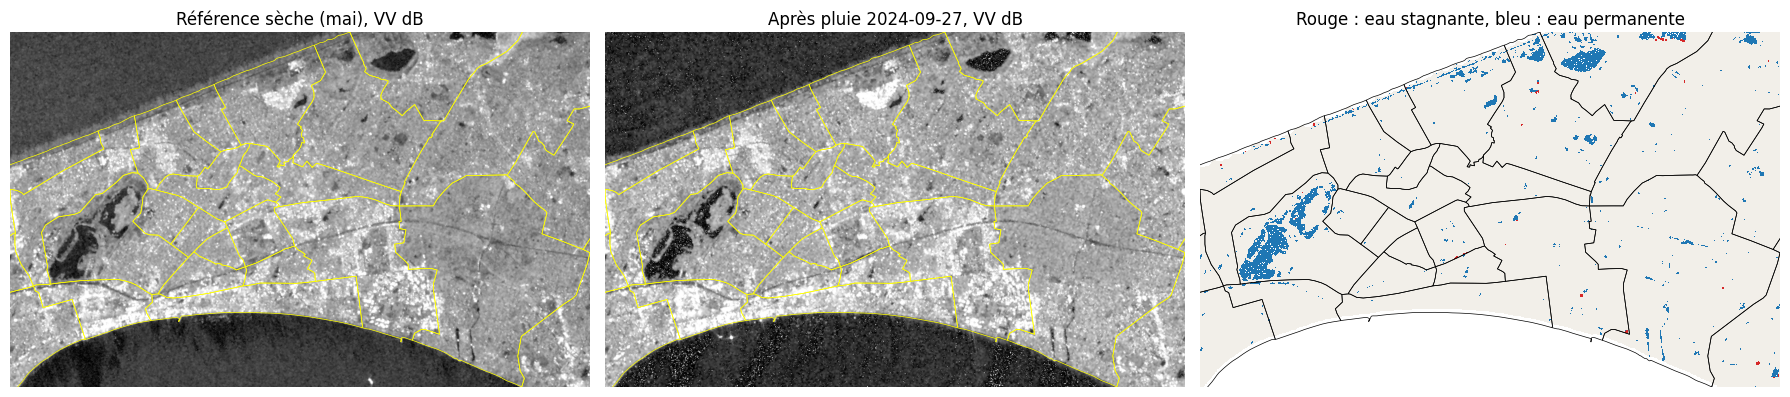

In [8]:
date_v = "2024-09-27"
zx0, zy0, zx1, zy1 = communes[communes.zone_prioritaire.isin(["Pikine", "Guédiawaye", "Yeumbeul"])].total_bounds
c0, c1 = int((zx0 - x0) / RES), int((zx1 - x0) / RES)
r0, r1 = int((y1 - zy1) / RES), int((y1 - zy0) / RES)
etendue = (zx0, zx1, zy0, zy1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6.5), sharex=True, sharey=True)
axes[0].imshow(REFERENCE[DATES_PLUIE[date_v]][r0:r1, c0:c1], cmap="gray", vmin=-25, vmax=0, extent=etendue)
axes[0].set_title("Référence sèche (mai), VV dB")
axes[1].imshow(filtre_lee(lire_db(date_v))[r0:r1, c0:c1], cmap="gray", vmin=-25, vmax=0, extent=etendue)
axes[1].set_title(f"Après pluie {date_v}, VV dB")
cl = classes[date_v][r0:r1, c0:c1].astype(float)
cl[cl == 255] = np.nan
axes[2].imshow(cl, cmap=plt.matplotlib.colors.ListedColormap(["#f2efe9", "#d62728", "#1f77b4"]), vmin=0, vmax=2,
               extent=etendue, interpolation="nearest")
axes[2].set_title("Rouge : eau stagnante, bleu : eau permanente")
for ax in axes:
    communes.boundary.plot(ax=ax, color="yellow" if ax is not axes[2] else "black", lw=0.5)
    ax.set_xlim(zx0, zx1); ax.set_ylim(zy0, zy1); ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUTPUTS / "verification_eau_s1.png", dpi=130, bbox_inches="tight")
plt.show()

## 8. Topographie : altitude, pente et dépressions par commune

**Source :** Copernicus DEM GLO-30, dalle `N14 W018`, téléchargée sans compte depuis `https://copernicus-dem-30m.s3.amazonaws.com/` et enregistrée dans `data/raw/copernicus_dem30_N14_W018.tif`.

**Indicateurs calculés par commune :**
- `alt_mediane_m` : altitude médiane. La médiane est moins sensible que la moyenne aux quelques pixels de grands bâtiments.
- `pct_sous_5m` : part de la surface sous 5 m d'altitude.
- `pct_depression` : part de la surface **plus basse d'au moins 1 m que son voisinage** dans une fenêtre d'environ 1 km (indice de position topographique). Ce sont les cuvettes où l'eau converge, même en altitude moyenne.

**Correction du bâti :** le DEM est un modèle de *surface*. Entre les toits, chaque rue ressortirait comme une petite « cuvette ». On approche donc d'abord le **sol nu** par une **ouverture morphologique** de 150 m : un filtre minimum puis un filtre maximum, qui efface tout objet plus étroit que 150 m, c'est-à-dire les bâtiments. L'altitude et les cuvettes sont calculées sur ce sol approché. Contrôle effectué : la corrélation entre l'indicateur de cuvettes et la hauteur du bâti tombe de 0,30 à 0,04.
- `pente_moy_deg` : pente moyenne. **Peu fiable en ville**, voir les limites.

In [9]:
from rasterio.warp import reproject, Resampling

FICHIER_DEM = PROJET / "data" / "raw" / "copernicus_dem30_N14_W018.tif"
if not FICHIER_DEM.exists():
    import requests
    url = ("https://copernicus-dem-30m.s3.amazonaws.com/Copernicus_DSM_COG_10_N14_00_W018_00_DEM/"
           "Copernicus_DSM_COG_10_N14_00_W018_00_DEM.tif")
    FICHIER_DEM.write_bytes(requests.get(url, timeout=300).content)

RES_DEM = 30
T_DEM = from_origin(x0, y1, RES_DEM, RES_DEM)
H_DEM, W_DEM = math.ceil((y1 - y0) / RES_DEM), math.ceil((x1 - x0) / RES_DEM)
dem = np.full((H_DEM, W_DEM), np.nan, dtype="float32")
with rasterio.open(FICHIER_DEM) as src:
    reproject(rasterio.band(src, 1), dem, dst_transform=T_DEM, dst_crs=CRS_METRES,
              resampling=Resampling.bilinear, dst_nodata=np.nan)

from scipy.ndimage import grey_opening

dem = np.nan_to_num(dem, nan=0.0)
sol = grey_opening(dem, size=(5, 5))            # sol approché : retire les objets < 150 m (bâtiments)
gy, gx = np.gradient(dem, RES_DEM)
pente = np.degrees(np.arctan(np.hypot(gx, gy)))
tpi = sol - uniform_filter(sol, 35)             # fenêtre de 35 x 30 m ≈ 1 km de côté

num_dem = rasterize(((g, i + 1) for i, g in enumerate(communes.geometry)),
                    out_shape=(H_DEM, W_DEM), transform=T_DEM, fill=0, dtype="int32")
topo = []
for i, c in communes.iterrows():
    m = num_dem == i + 1
    topo.append({"osm_id": c["osm_id"], "commune": c["commune"],
                 "alt_mediane_m": round(float(np.median(sol[m])), 2),
                 "alt_moyenne_m": round(float(np.mean(sol[m])), 2),
                 "alt_mediane_surface_m": round(float(np.median(dem[m])), 2),
                 "pct_sous_5m": round(float(100 * np.mean(sol[m] < 5)), 2),
                 "pct_depression": round(float(100 * np.mean(tpi[m] < -1)), 2),
                 "pente_moy_deg": round(float(np.nanmean(pente[m])), 2),
                 "n_pixels_dem": int(m.sum())})
topo = pd.DataFrame(topo).sort_values("alt_mediane_m").reset_index(drop=True)
FICHIER_TOPO = PROCESSED / "topo_communes.csv"
topo.to_csv(FICHIER_TOPO, index=False, encoding="utf-8")
print("Enregistré :", FICHIER_TOPO)
topo.head(15)

Enregistré : C:\Users\Administrateur\Documents\dakar-risque-inondation\data\processed\topo_communes.csv


,osm_id,commune,alt_mediane_m,alt_moyenne_m,alt_mediane_surface_m,pct_sous_5m,pct_depression,pente_moy_deg,n_pixels_dem
0,12989303,Pikine Ouest,2.34,4.57,2.93,65.67,44.42,1.52,6405
1,12982161,Sendou,2.52,3.15,2.92,81.56,8.12,0.79,9071
2,12989394,Thiaroye-sur-Mer,4.98,4.91,5.72,50.32,4.69,1.78,4028
3,12989305,Guinaw Rail Sud,5.08,5.61,5.89,47.91,25.38,1.51,1505
4,12982148,Malika,5.30,5.01,5.88,47.01,34.68,1.85,12071
5,12989302,Dalifort,5.34,5.28,5.92,44.76,11.93,1.73,2708
6,12988835,Hann Bel-Air,5.62,6.13,6.60,41.64,18.93,2.15,13980
7,12982149,Keur Massar Nord,5.71,5.30,6.27,42.83,28.02,1.37,14648
8,12989306,Guinaw Rail Nord,5.78,5.87,6.16,12.23,16.76,1.01,728
9,12989395,Tivaouane Diacksao,5.84,5.80,6.44,15.20,12.75,1.27,1184


## Limites de ce résultat

- **Bâti dense sous-estimé :** dans une rue étroite inondée, le signal radar ricoche entre l'eau et les façades (effet de « double rebond ») et ne ressort pas sombre. Le radar voit bien l'eau dans les **zones ouvertes, sableuses et les bas-fonds**. Il la voit mal dans le tissu très construit (Médina, centre de Pikine). **Un score faible en zone dense ne veut pas dire « pas d'inondation ».**
- **3 dates seulement, avec un passage tous les 12 jours :** on voit l'eau qui **persiste** 1 à 5 jours après la pluie, pas le pic de crue. Le score mesure une tendance à retenir l'eau, pas une fréquence d'inondation.
- **Pixels de 10 m :** une flaque de rue de quelques mètres est invisible. Seules les étendues de plusieurs centaines de m² sont détectées.
- **Eau permanente :** le masque « déjà sombre en saison sèche » regroupe lacs, bassins, mais aussi sable très sec et grandes surfaces lisses (pistes, parkings). Une vraie zone inondable qui serait déjà humide en mai serait ratée, mais c'est rare à Dakar.
- **Végétation :** une eau sous la végétation (Niayes maraîchères) peut au contraire *augmenter* le signal radar, et ne pas être détectée.
- Le choix des seuils (-15 à -22 dB, baisse de 3 dB) est **standard mais pas validé sur le terrain à Dakar**. Une validation avec des photos ou des signalements de 2024-2025 serait l'étape suivante.
- **Résultat constaté :** seulement 0,1 à 0,3 % de la terre ferme est détecté en eau stagnante, principalement en zone périurbaine ouverte (Tivaouane Peulh, Bargny, Yenne) et dans quelques communes de Guédiawaye et Pikine. Le tissu dense de Pikine et Thiaroye ressort à 0 %. **C'est une limite de la méthode, pas une preuve d'absence d'inondation.** Cet indicateur ne doit peser que modérément dans le score composite.
- **Bande côtière de 100 m exclue** : une inondation sur le front de mer immédiat ne serait pas comptée.

### Topographie
- Le Copernicus DEM est un **modèle de surface** : il inclut les bâtiments et les arbres. En zone dense, l'altitude est surestimée de quelques mètres, et la **pente mesure surtout les bords des toits**, pas le relief du sol. La pente n'est donc pas un bon indicateur ici.
- La précision verticale annoncée est d'environ 2 m (erreur absolue à 90 %), du même ordre que les écarts entre communes basses. Un écart de 1 à 2 m d'altitude médiane entre deux communes **n'est pas significatif**.
- Une résolution de 30 m reste grossière face au réseau de rues et de canaux. Les chemins d'écoulement fins ne sont pas représentés.